In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.colors as mcolors
import json
import numpy as np
from matplotlib.patches import Patch

plt.style.use("~/PhD/Literature/MATPLOTLIB_RCPARAMS.sty")

In [2]:
# import json file
with open('mf_data.json') as json_file:
    data = json.load(json_file)

for key, value in data.items():
        locals()[key] = np.array(value)

In [3]:
mf_minus_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_minus.T))
mf_plus_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_plus.T))

In [4]:
def hist_plot(ell, sign, savefig, xlim): 

    fig = plt.figure()
    ax1 = fig.add_subplot(111)

    if sign == '+':
        mf_list = [mf_plus_dict[(ell,l)] for l in range(ell,0,-1)]
    else:
        mf_list = [mf_minus_dict[(ell,l)] for l in range(ell,0,-1)]

    label_list = [r'$\mathfrak{m}^%s_{%s,%s}$' %(sign, ell, l) for l in range(ell,0,-1)]

    hist, bin_edges, patches = ax1.hist(mf_list, bins=350, histtype='stepfilled', alpha=.5, label=label_list) 

    for i in range(len(hist)):
        peaks, _ = find_peaks(hist[i], distance=20, height=25)
        for peak in peaks:
            ax1.axvline(bin_edges[peak], color=list(mcolors.TABLEAU_COLORS.values())[i], linestyle=':')

    ax1.set_xlim(0,xlim)
    ax1.set_ylabel(r'$\#$')
    ax1.set_xlabel(r'$\mathfrak{m}^%s$' %sign)
    ax1.legend(loc='upper left')
    ax1.set_title(r'$\ell=%s,\quad\dot{\phi}^%s/\dot{\Phi}$' %(ell, sign))

    if savefig:
        plt.savefig('mf_%s_insp_SXS_l%s.pdf' %(sign, ell))
    plt.show()

In [5]:
for mode in mode_list_m_pos:
    l, m = mode[0], mode[1]
    mf_lm = mf_plus_dict[(l,m)]
    print((l, m),': ', np.round(np.median(mf_lm),3))

(2, 0) :  0.0
(2, 1) :  1.0
(2, 2) :  2.0
(3, 0) :  -0.0
(3, 1) :  0.999
(3, 2) :  2.0
(3, 3) :  3.001
(4, 0) :  0.0
(4, 1) :  0.997
(4, 2) :  1.999
(4, 3) :  3.0
(4, 4) :  4.0
(5, 0) :  0.0
(5, 1) :  1.003
(5, 2) :  1.998
(5, 3) :  3.0
(5, 4) :  3.999
(5, 5) :  5.0
(6, 0) :  0.0
(6, 1) :  1.193
(6, 2) :  1.96
(6, 3) :  3.0
(6, 4) :  4.0
(6, 5) :  4.999
(6, 6) :  5.999
(7, 0) :  -0.0
(7, 1) :  0.041
(7, 2) :  2.025
(7, 3) :  2.991
(7, 4) :  4.001
(7, 5) :  5.0
(7, 6) :  5.998
(7, 7) :  6.999
(8, 0) :  0.0
(8, 1) :  1.249
(8, 2) :  0.038
(8, 3) :  3.078
(8, 4) :  3.107
(8, 5) :  4.995
(8, 6) :  5.996
(8, 7) :  6.998
(8, 8) :  7.999


# $\ell = 2$

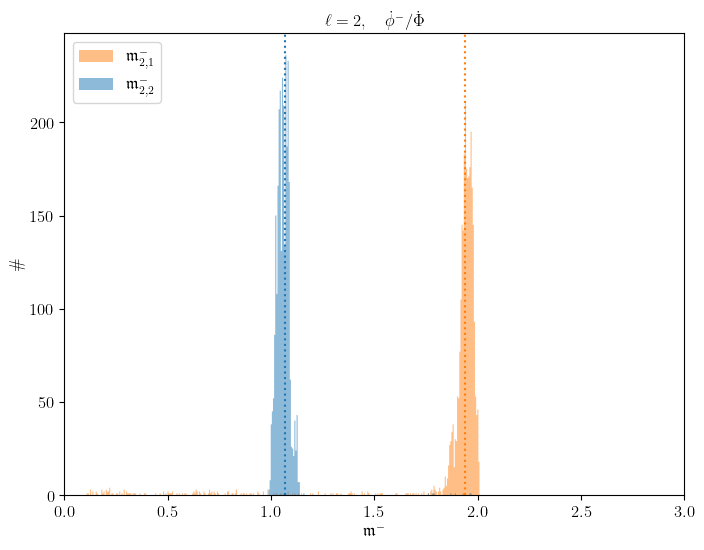

In [6]:
hist_plot(ell=2, sign='-', savefig=False, xlim=3)

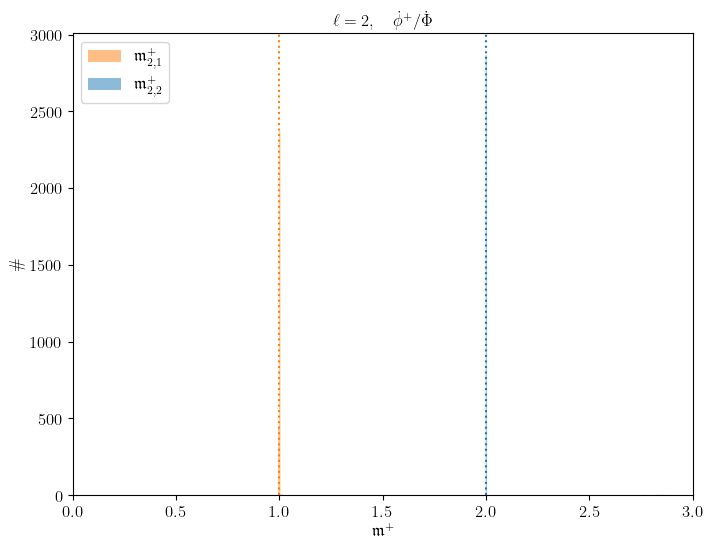

In [7]:
hist_plot(ell=2, sign='+', savefig=False, xlim=3)

# $\ell=3$

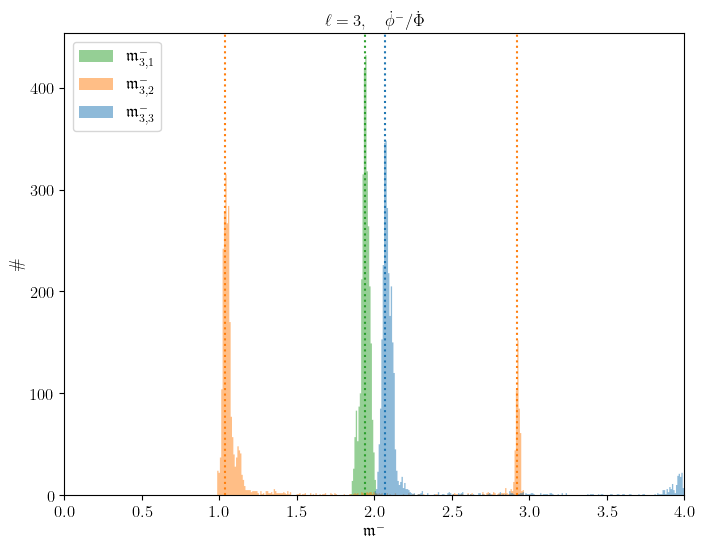

In [8]:
hist_plot(ell=3, sign='-', savefig=False, xlim=4)

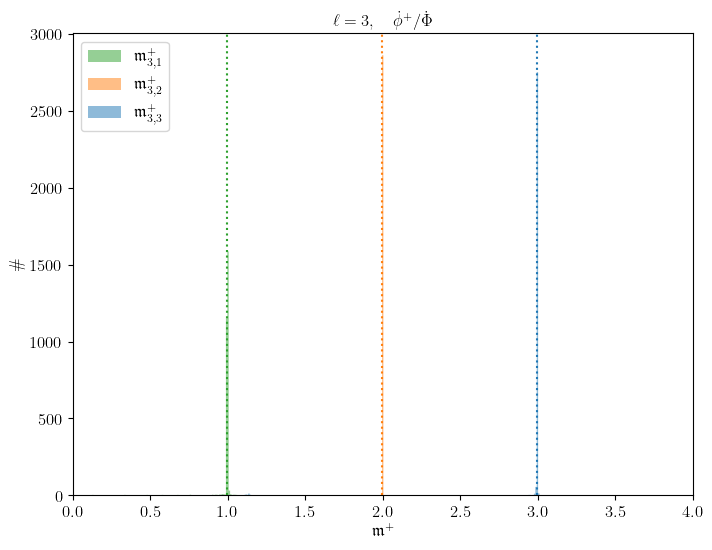

In [9]:
hist_plot(ell=3, sign='+', savefig=False, xlim=4)

# $\ell=4$

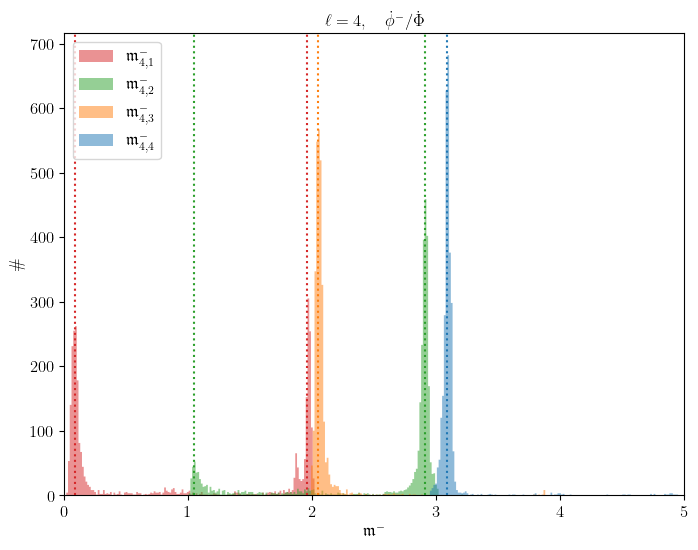

In [10]:
hist_plot(ell=4, sign='-', savefig=False, xlim=5)

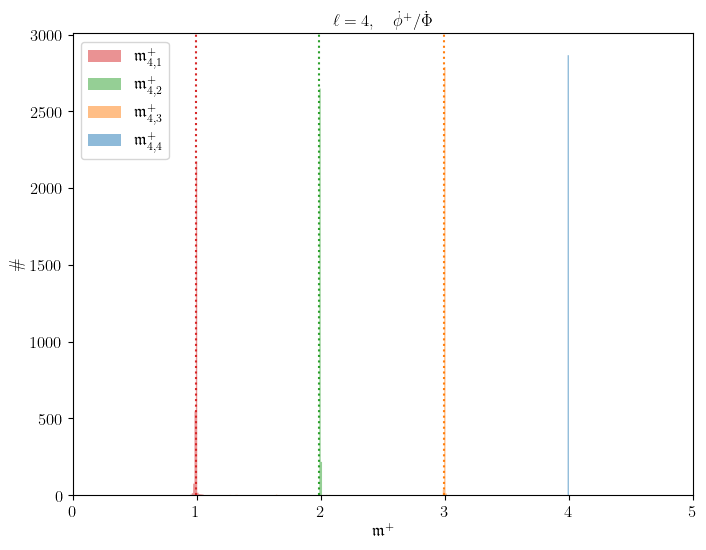

In [11]:
hist_plot(ell=4, sign='+', savefig=False, xlim=5)

# $\ell = 5$

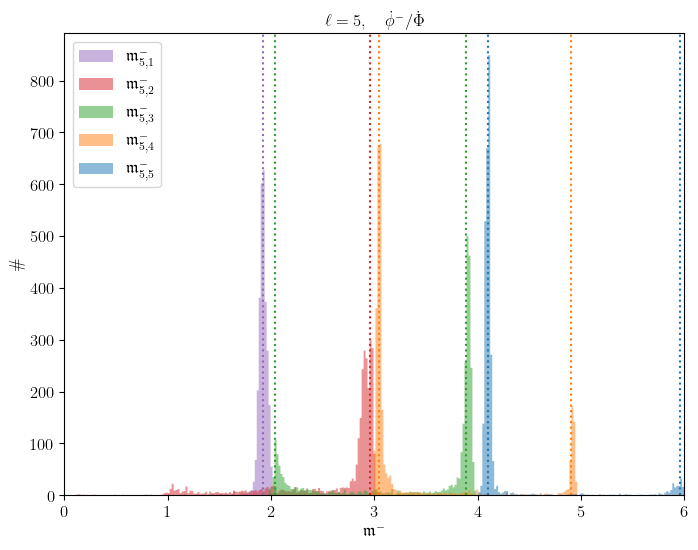

In [12]:
hist_plot(ell=5, sign='-', savefig=False, xlim=6)

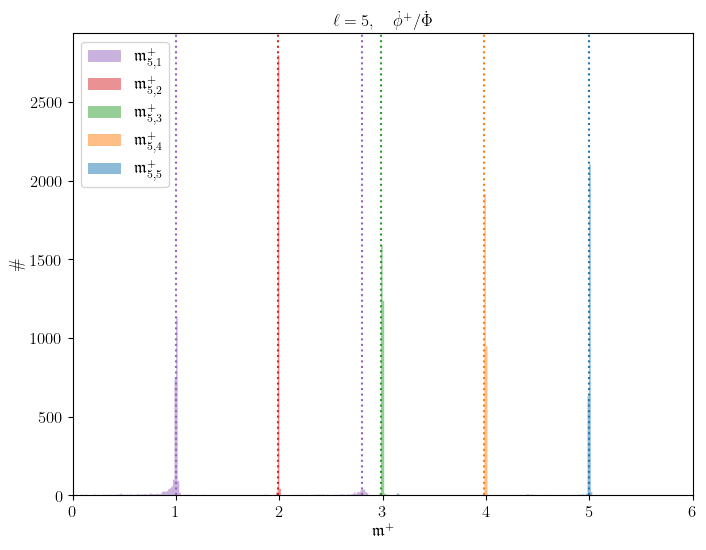

In [13]:
hist_plot(ell=5, sign='+', savefig=False, xlim=6)

# $\ell=6$

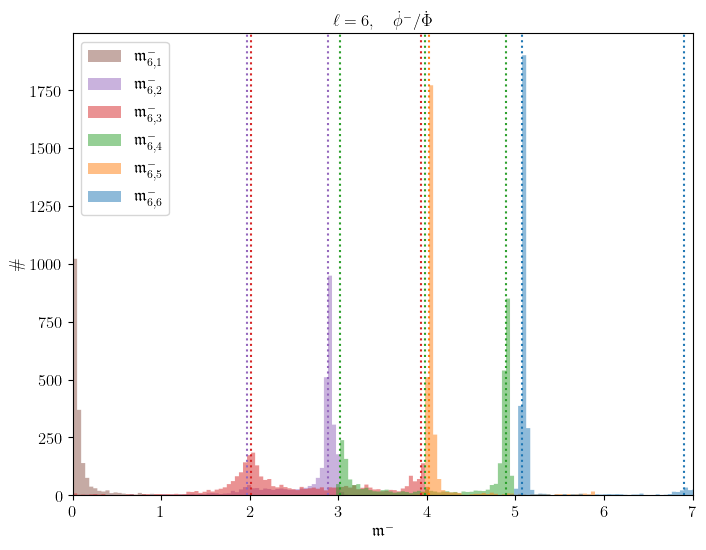

In [14]:
hist_plot(ell=6, sign='-', savefig=False, xlim=7)

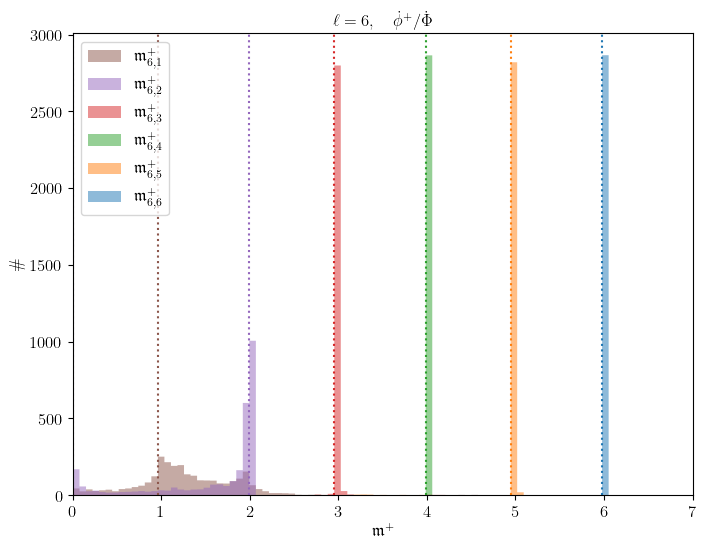

In [15]:
hist_plot(ell=6, sign='+', savefig=False, xlim=7)

# $\ell = 7$

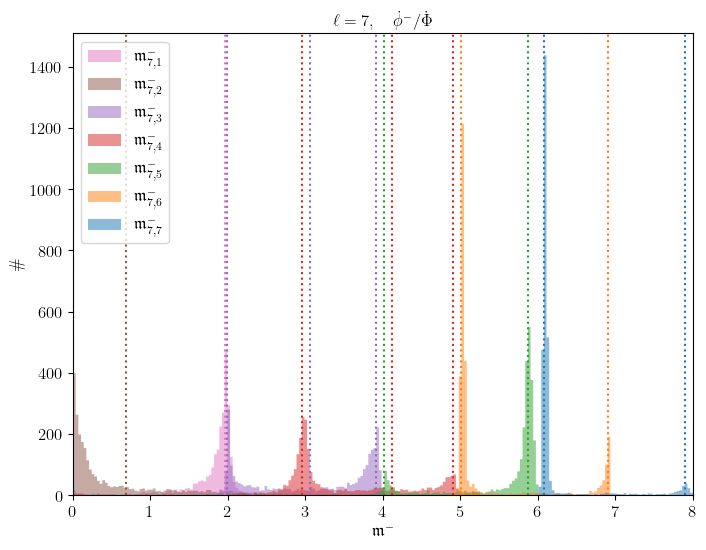

In [16]:
hist_plot(ell=7, sign='-', savefig=False, xlim=8)

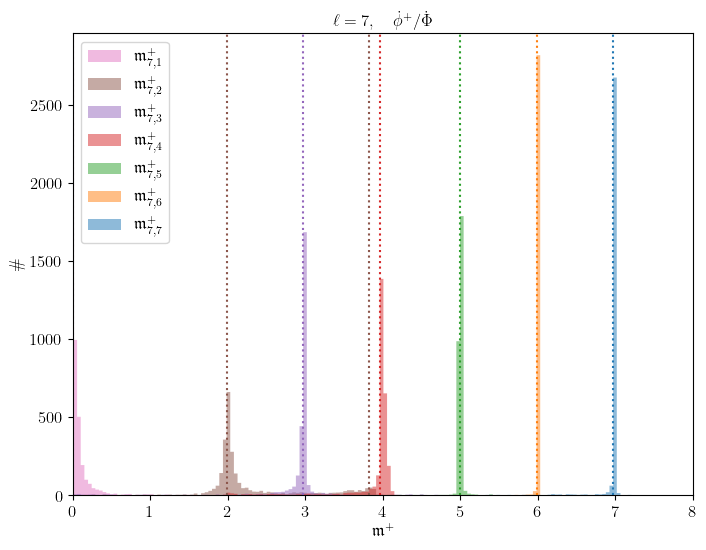

In [17]:
hist_plot(ell=7, sign='+', savefig=False, xlim=8)

# $\ell=8$

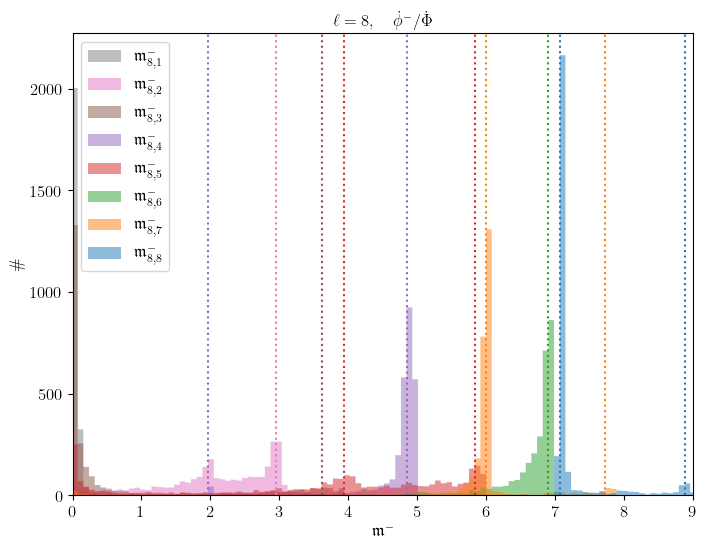

In [18]:
hist_plot(ell=8, sign='-', savefig=False, xlim=9)

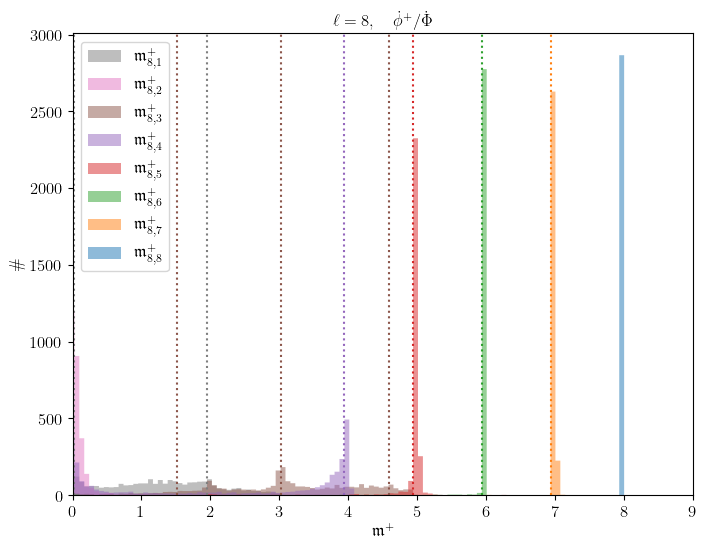

In [19]:
hist_plot(ell=8, sign='+', savefig=False, xlim=9)

# Single analysis of special magic factors

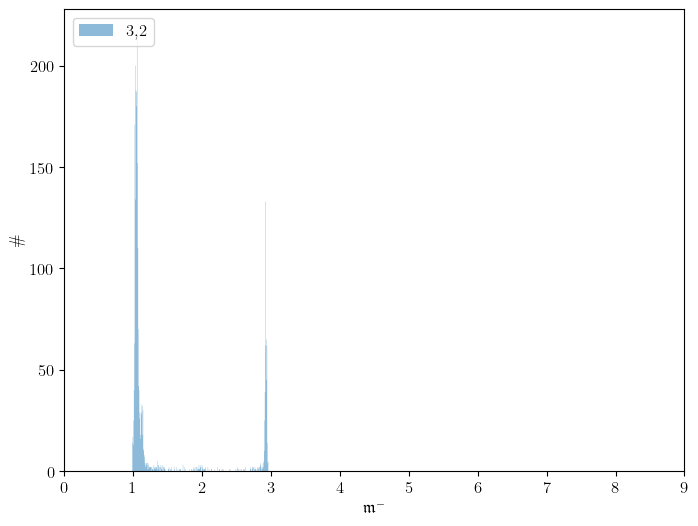

In [20]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

ell = 3
m = 2

ax1.hist(mf_minus_dict[(ell, m)], bins=350, histtype='stepfilled', alpha=.5, label='%s,%s'%(ell,m))

ax1.set_xlim(0,9)
ax1.set_ylabel(r'$\#$')
ax1.set_xlabel(r'$\mathfrak{m}^-$')
ax1.legend(loc='upper left')

plt.show()



# Violine Plots

In [21]:
# global matplotlib settings
size = 18
params = {'xtick.labelsize' : size, 
          'ytick.labelsize' : size, 
          'axes.labelsize' : size, 
          'legend.fontsize' : size, 
          'font.size' : size,
          'axes.titlesize': size
         }
plt.rcParams.update(params)

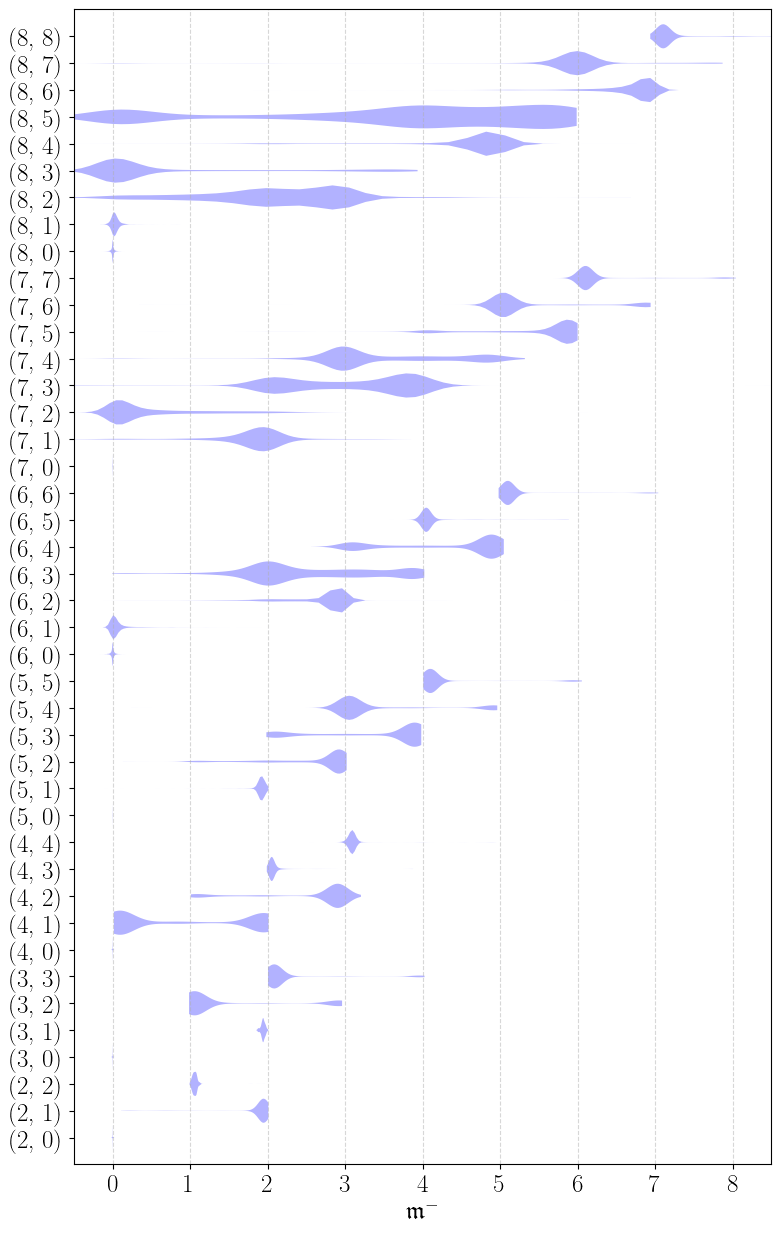

In [22]:

fig = plt.figure(figsize=(9,15))
ax1 = fig.add_subplot(111)


selected_keys = [key for key in mf_minus_dict.keys() if key <= (8, 8)]
data = [mf_minus_dict[key] for key in selected_keys]

parts = ax1.violinplot(
    data,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    vert=False,
    widths=0.9
)

for body in parts['bodies']:
    body.set_facecolor('blue') 
    #body.set_edgecolor('black')
    #body.set_alpha(0.7)

ax1.set_yticks(range(1, len(selected_keys) + 1))
ax1.set_yticklabels([str(key) for key in selected_keys])
ax1.set_xlabel(r'$\mathfrak{m}^-$')
ax1.set_xlim(-.5, 8.5)
ax1.set_ylim(0, len(selected_keys) + 1)
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')

# plt.savefig('mf_minus_violin_plot_code2602b.pdf', bbox_inches='tight')
plt.show()

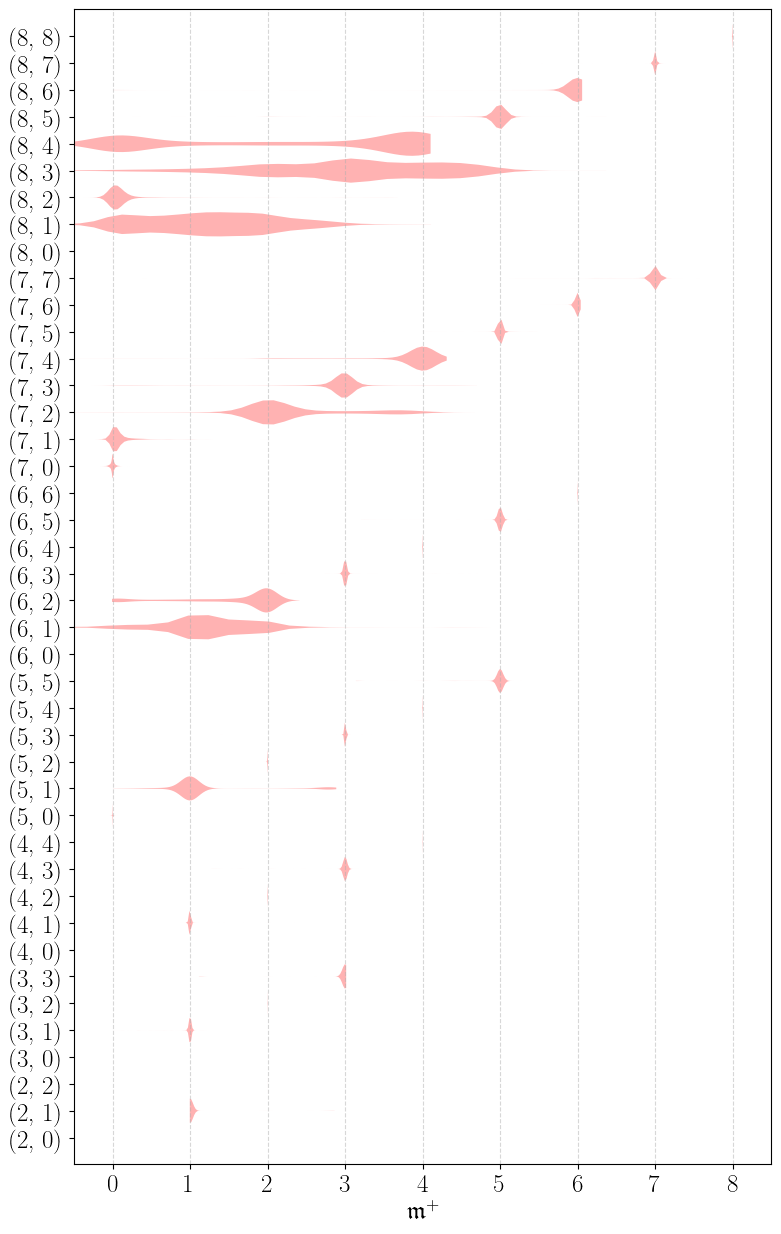

In [23]:
fig = plt.figure(figsize=(9,15))
ax1 = fig.add_subplot(111)


selected_keys = [key for key in mf_plus_dict.keys() if key <= (8, 8)]
data = [mf_plus_dict[key] for key in selected_keys]

parts = ax1.violinplot(
    data,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    vert=False,
    widths=0.9
)

for body in parts['bodies']:
    body.set_facecolor('red') 
    #body.set_edgecolor('black')
    #body.set_alpha(0.7)

ax1.set_yticks(range(1, len(selected_keys) + 1))
ax1.set_yticklabels([str(key) for key in selected_keys])
ax1.set_xlabel(r'$\mathfrak{m}^+$')
ax1.set_xlim(-.5, 8.5)
ax1.set_ylim(0, len(selected_keys) + 1)
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')

# plt.savefig('mf_minus_violin_plot_code2606b.pdf', bbox_inches='tight')
plt.show()

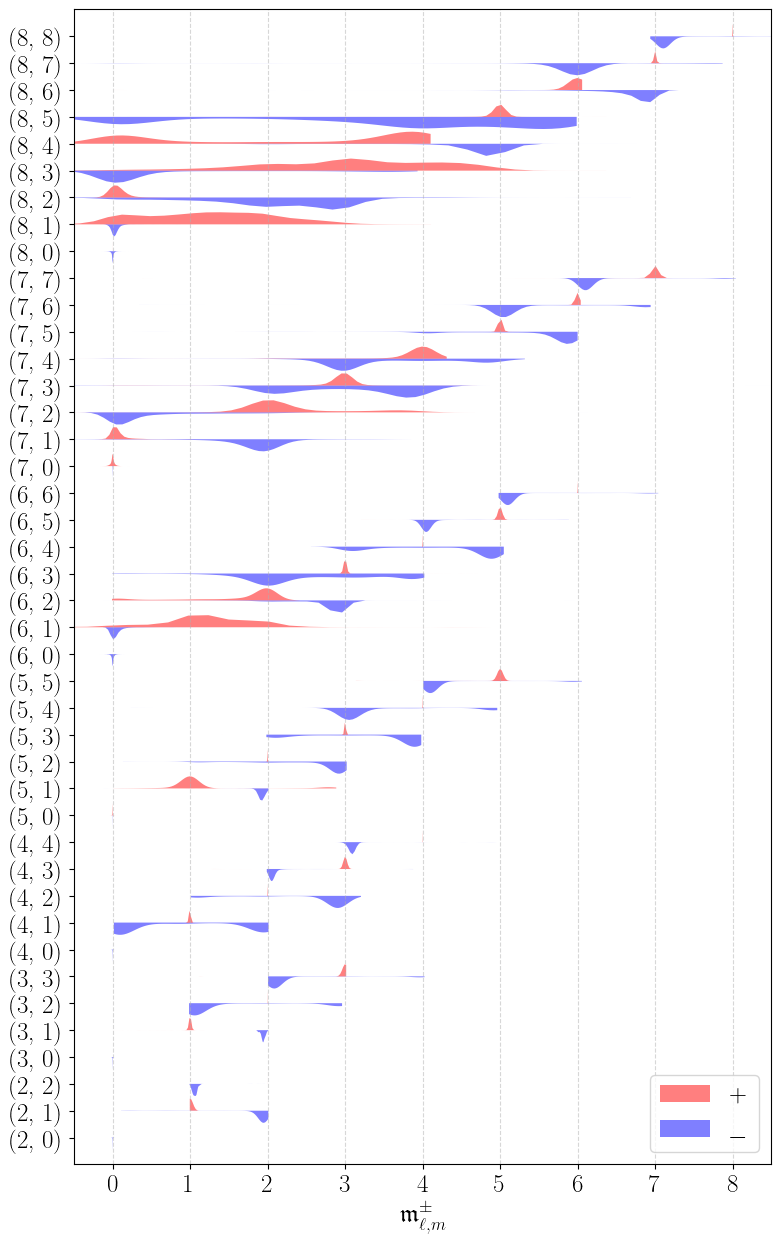

In [24]:
fig = plt.figure(figsize=(9,15))
ax1 = fig.add_subplot(111)


selected_keys = [key for key in mf_minus_dict.keys() if key <= (8, 8)]
data = [mf_minus_dict[key] for key in selected_keys] 
parts = ax1.violinplot(
    data,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    vert=False,
    widths=0.9
)

for body in parts['bodies']:
    path = body.get_paths()[0]
    vertices = path.vertices
    x = vertices[:, 0]
    y = vertices[:, 1]
    center = np.mean(y)
    y_new = np.where(y > center, center, y)
    vertices[:, 1] = y_new
    body.set_facecolor('blue')
    body.set_alpha(0.5)



selected_keys = [key for key in mf_plus_dict.keys() if key <= (8, 8)]
data = [mf_plus_dict[key] for key in selected_keys] 

parts = ax1.violinplot(
    data,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    vert=False,
    widths=0.9
)

for body in parts['bodies']:
    path = body.get_paths()[0]
    vertices = path.vertices
    x = vertices[:, 0]
    y = vertices[:, 1]
    center = np.mean(y)
    y_new = np.where(y < center, center, y)
    vertices[:, 1] = y_new
    body.set_facecolor('red')
    body.set_alpha(0.5)

ax1.set_yticks(range(1, len(selected_keys) + 1))
ax1.set_yticklabels([str(key) for key in selected_keys])
ax1.set_xlabel(r'$\mathfrak{m}^\pm_{\ell,m}$')
ax1.set_xlim(-.5, 8.5)
ax1.set_ylim(0, len(selected_keys) + 1)
ax1.grid(True, linestyle='--', alpha=0.5, axis='x') 


legend_elements = [
    Patch(facecolor='red', edgecolor='none', alpha=0.5, label=r'$+$'),
    Patch(facecolor='blue', edgecolor='none', alpha=0.5, label=r'$-$'),
]

ax1.legend(handles=legend_elements, loc='lower right')

# plt.savefig('mf_pm_violin_plot_tref_to_100.pdf', bbox_inches='tight')
plt.show()